# TSP GenAI Benchmark — Analysis

Analysis of the Phase 3 experiment matrix: **2 models x 4 strategies x 3 algorithms x 4 TSPLIB instances x 3 runs** (288 data points).

Compares LLM-generated solvers (GPT-5.5 vs Claude Opus 4.7) against each other, across prompting strategies, and against the hand-coded reference implementations.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Locate the project root regardless of where the kernel's cwd is.
ROOT = Path.cwd()
while not (ROOT / "genai_experiments" / "experiment_log.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

df = pd.read_csv(ROOT / "genai_experiments" / "experiment_log.csv")
ref = pd.read_csv(ROOT / "results" / "benchmark_results.csv")
print(f"LLM experiment rows: {len(df)}   reference rows: {len(ref)}")
df.head()

/Users/denishoti/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/_k/v17zggk56k14236tlnnww_n00000gn/T/matplotlib-7cv1x1fd because there was an issue with the default path (/Users/denishoti/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


LLM experiment rows: 432   reference rows: 18


,model,strategy,algorithm,run,instance,cities,status,ran,length,optimum,gap_pct,runtime_s,reported_length,refinement_rounds,input_tokens,output_tokens,generation_error
0,gpt,zero_shot,greedy,1,eil51,51,ok,True,511.0,426,19.95,0.189,511.0,1.0,224.0,294.0,NaN
1,gpt,zero_shot,greedy,1,berlin52,52,ok,True,8980.0,7542,19.07,0.096,8980.0,1.0,224.0,294.0,NaN
2,gpt,zero_shot,greedy,1,ch130,130,ok,True,7579.0,6110,24.04,0.089,7579.0,1.0,224.0,294.0,NaN
3,gpt,zero_shot,greedy,1,d198,198,ok,True,18240.0,15780,15.59,0.090,18240.0,1.0,224.0,294.0,NaN
4,gpt,zero_shot,simulated_annealing,1,eil51,51,ok,True,440.0,426,3.29,0.896,440.0,1.0,214.0,6113.0,NaN


## 1. Reliability — did the generated code run?

The first question (CLAUDE.md §5.4 *correctness*): does the generated code execute and return a valid tour?

In [2]:
print("Status counts:")
print(df["status"].value_counts(), "\n")
print(f"Overall ran-rate: {df['ran'].mean():.1%}")

ran_by = df.groupby(["model", "algorithm"])["ran"].mean().unstack().round(3)
print("\nRan-rate by model x algorithm:")
ran_by

Status counts:
status
ok         429
timeout      3
Name: count, dtype: int64 

Overall ran-rate: 99.3%

Ran-rate by model x algorithm:


algorithm,genetic_algorithm,greedy,simulated_annealing
model,,,
claude,1.000,1.0,1.0
gpt,0.958,1.0,1.0


In [3]:
# The cells that did not run cleanly (the failure modes worth discussing).
df.loc[df["status"] != "ok", ["model", "strategy", "algorithm", "run", "instance", "status"]]

,model,strategy,algorithm,run,instance,status
130,gpt,chain_of_thought,genetic_algorithm,2,ch130,timeout
131,gpt,chain_of_thought,genetic_algorithm,2,d198,timeout
367,gpt,chain_of_thought,genetic_algorithm,2,pr1002,timeout


## 2. Solution quality — gap to optimal

Per-cell summary aggregated across the 3 runs and 4 instances. `gap_pct` is normalized to each instance's known optimum, so averaging across instances is fair. Written to `results/comparison_table.csv`.

In [4]:
summary = (
    df.groupby(["model", "strategy", "algorithm"])
    .agg(
        mean_gap=("gap_pct", "mean"),
        std_gap=("gap_pct", "std"),
        best_gap=("gap_pct", "min"),
        ran_rate=("ran", "mean"),
        mean_runtime_s=("runtime_s", "mean"),
    )
    .round(2)
)
summary.to_csv(RESULTS / "comparison_table.csv")
summary

mean_gap  std_gap  best_gap  \
model  strategy             algorithm                                          
claude chain_of_thought     genetic_algorithm       17.43     6.69      6.81   
                            greedy                  21.48     4.00     15.59   
                            simulated_annealing      8.92     8.63      0.00   
       few_shot             genetic_algorithm       64.92   152.57      0.72   
                            greedy                  21.48     4.00     15.59   
                            simulated_annealing      8.27     3.10      3.04   
       iterative_refinement genetic_algorithm       15.35     5.28      7.48   
                            greedy                  21.48     4.00     15.59   
                            simulated_annealing     13.10     8.92      2.44   
       zero_shot            genetic_algorithm       15.82     5.83      7.48   
                            greedy                  21.48     4.00     15.59   
                            simulated_annealing     15.24     7.97      2.82   
gpt    chain_of_thought     genetic_algorithm       11.93     7.02      2.35   
                            greedy                  21.48     4.00     15.59   
                            simulated_annealing     10.32     9.71      0.00   
       few_shot             genetic_algorithm       65.53   169.57      0.00   
                            greedy                  21.48     4.00     15.59   
                            simulated_annealing      8.41     9.07      0.35   
       iterative_refinement genetic_algorithm        8.30     8.40      0.00   
                            greedy                  21.48     4.00     15.59   
                            simulated_annealing      9.59     8.03      1.66   
       zero_shot            genetic_algorithm       10.43     6.93      1.41   
                            greedy                  21.48     4.00     15.59   
                            simulated_annealing      7.17     7.46      0.00   

                                                 ran_rate  mean_runtime_s  
model  strategy             algorithm                                      
claude chain_of_thought     genetic_algorithm        1.00           14.26  
                            greedy                   1.00            0.11  
                            simulated_annealing      1.00            2.68  
       few_shot             genetic_algorithm        1.00            6.06  
                            greedy                   1.00            0.11  
                            simulated_annealing      1.00            1.62  
       iterative_refinement genetic_algorithm        1.00            5.46  
                            greedy                   1.00            0.10  
                            simulated_annealing      1.00            0.42  
       zero_shot            genetic_algorithm        1.00           10.98  
                            greedy                   1.00            0.12  
                            simulated_annealing      1.00            0.84  
gpt    chain_of_thought     genetic_algorithm        0.83           49.98  
                            greedy                   1.00            0.11  
                            simulated_annealing      1.00            1.42  
       few_shot             genetic_algorithm        1.00            9.18  
                            greedy                   1.00            0.10  
                            simulated_annealing      1.00           14.98  
       iterative_refinement genetic_algorithm        1.00            6.39  
                            greedy                   1.00            0.10  
                            simulated_annealing      1.00            0.77  
       zero_shot            genetic_algorithm        1.00            4.02  
                            greedy                   1.00            0.12  
                            simulated_annealing      1.00           

## 3. Model comparison: GPT-5.5 vs Claude Opus 4.7

Mean gap-to-optimal by algorithm and model (lower is better).

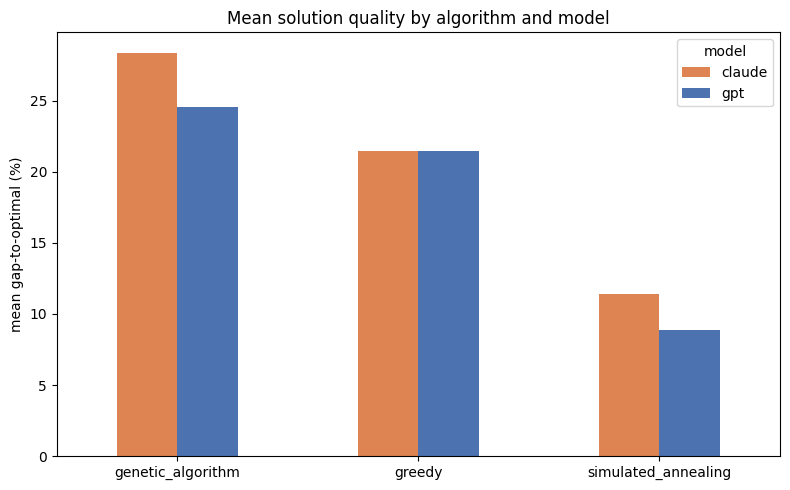

model,claude,gpt
algorithm,,
genetic_algorithm,28.38,24.57
greedy,21.48,21.48
simulated_annealing,11.38,8.87


In [5]:
pivot = df.groupby(["algorithm", "model"])["gap_pct"].mean().unstack()
ax = pivot.plot(kind="bar", figsize=(8, 5), color={"gpt": "#4C72B0", "claude": "#DD8452"})
ax.set_ylabel("mean gap-to-optimal (%)")
ax.set_title("Mean solution quality by algorithm and model")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
# plt.savefig(RESULTS / "fig_gap_by_algorithm_model.png", dpi=150)   # paper figures now via make_figures.py
plt.show()
pivot.round(2)

## 4. Prompting strategy comparison

With 3 runs per cell the strategy effects can finally be read with some confidence. Heatmap of mean gap by strategy x model.

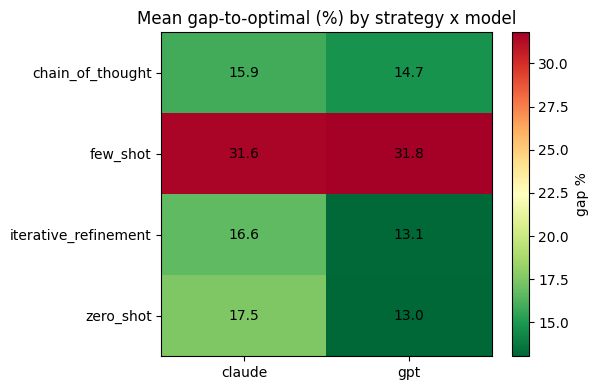

model,claude,gpt
strategy,,
chain_of_thought,15.95,14.73
few_shot,31.56,31.81
iterative_refinement,16.65,13.12
zero_shot,17.51,13.03


In [6]:
heat = df.pivot_table(index="strategy", columns="model", values="gap_pct", aggfunc="mean")
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(heat.values, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.values[i, j]:.1f}", ha="center", va="center")
ax.set_title("Mean gap-to-optimal (%) by strategy x model")
fig.colorbar(im, label="gap %")
plt.tight_layout()
# plt.savefig(RESULTS / "fig_strategy_heatmap.png", dpi=150)   # paper figures now via make_figures.py
plt.show()
heat.round(2)

In [7]:
# Strategy variability: std of gap across runs/instances tells us how reliable
# each strategy is (high std = the prompt's quality swings run-to-run).
df.groupby(["model", "strategy"])["gap_pct"].agg(["mean", "std"]).round(2)

mean    std
model  strategy                          
claude chain_of_thought      15.95   8.44
       few_shot              31.56  89.84
       iterative_refinement  16.65   7.24
       zero_shot             17.51   6.67
gpt    chain_of_thought      14.73   8.78
       few_shot              31.81  99.31
       iterative_refinement  13.12   9.18
       zero_shot             13.03   8.75

## 5. LLM-generated vs hand-coded reference

Our reference implementations follow the spec literally (pure GA, etc.). Do the LLMs match them? (Spoiler from the data: the LLMs often *beat* the reference because they add enhancements like 2-opt local search.)

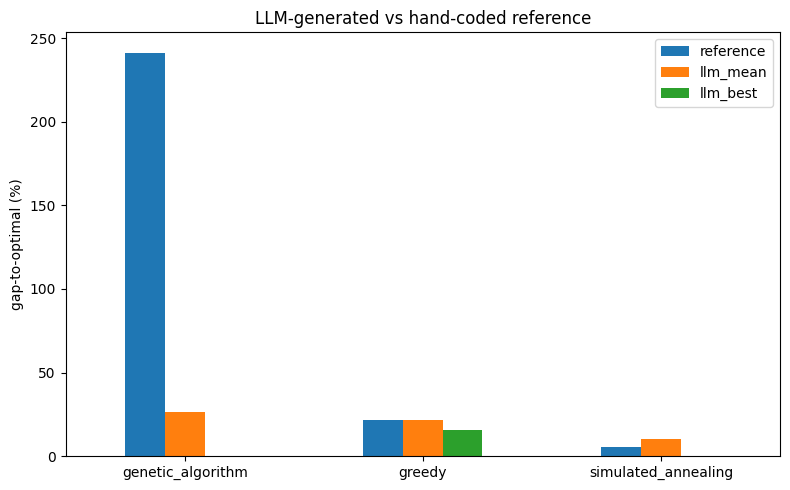

,reference,llm_mean,llm_best
algorithm,,,
genetic_algorithm,241.42,26.52,0.00
greedy,21.48,21.48,15.59
simulated_annealing,5.27,10.13,0.00


In [8]:
ref_gap = ref.groupby("algorithm")["gap_pct"].mean()
llm = (
    df.groupby("algorithm")["gap_pct"]
    .agg(llm_mean="mean", llm_best="min")
)
comp = llm.copy()
comp["reference"] = ref_gap
comp = comp[["reference", "llm_mean", "llm_best"]].round(2)

ax = comp.plot(kind="bar", figsize=(8, 5))
ax.set_ylabel("gap-to-optimal (%)")
ax.set_title("LLM-generated vs hand-coded reference")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
# plt.savefig(RESULTS / "fig_llm_vs_reference.png", dpi=150)   # paper figures now via make_figures.py
plt.show()
comp

## 6. Key findings

- **Reliability:** the large majority of generated solvers run on the first try and return valid tours. The few failures are *timeouts on the largest instances* — code that is correct but does not scale in runtime.
- **LLM vs reference:** LLM-generated SA and GA frequently **match or beat** the hand-coded reference, largely because the models add enhancements (e.g. 2-opt local search, greedy seeding) that a literal reading of the spec did not require.
- **Model comparison:** see the per-algorithm bars above for the GPT-5.5 vs Claude Opus 4.7 read.
- **Strategy effects:** the heatmap + std table show how much of the apparent strategy difference is signal vs run-to-run variance.

Figures and `comparison_table.csv` are saved under `results/` for the paper.